In [25]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

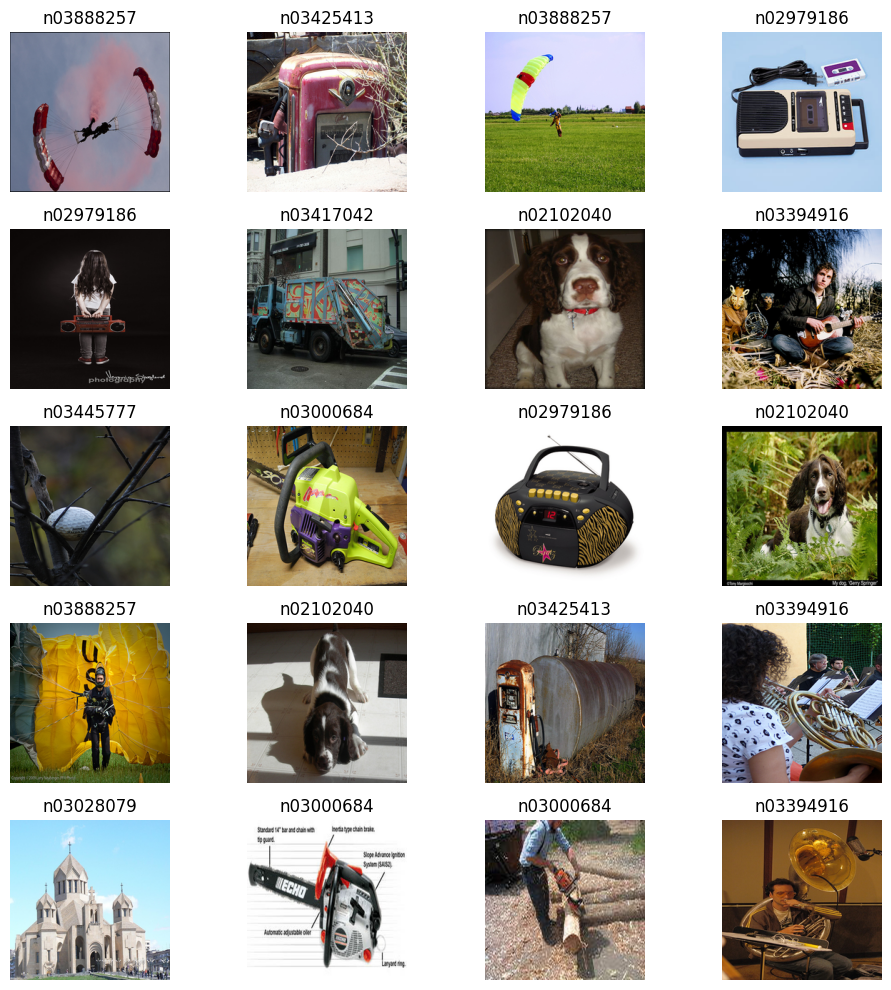

In [3]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [22]:
layer_definitions = [
    {"type": "Conv", "num_filters": 32, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 3, "pool_width": 3, "stride": 2},
    {"type": "Conv", "num_filters": 16, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2}
]

network = Network(layer_definitions=layer_definitions)

In [23]:
network.describe()

Network Architecture

Layer 1: ConvLayer
  Filters Shape: (32, 3, 3, 3)
  Parameters: 864

Layer 2: MaxPoolLayer
  Pool Shape: (3, 3) | Stride: 2

Layer 3: ConvLayer
  Filters Shape: (16, 32, 3, 3)
  Parameters: 4,608

Layer 4: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Total Parameters: 5,472


In [24]:
output = network.forward(x_train[:100])
output

[array([[[[ 7.71652154,  8.76105002,  8.16575662, ...,  9.30633792,
            9.36418661,  9.49061265],
          [ 8.31554584,  8.4165233 ,  8.11422807, ...,  8.82593656,
            8.77384302,  8.9029475 ],
          [ 8.30821724,  7.49391076,  7.3073049 , ...,  8.75987305,
            8.81289872,  8.6382593 ],
          ...,
          [ 7.94351594,  7.4308252 ,  7.35948223, ...,  7.09589518,
            7.92725283,  7.99355483],
          [ 7.81645923,  7.39769024,  6.99565642, ...,  7.90596981,
            8.28432179,  7.34357456],
          [ 7.28373244,  7.23324559,  7.08794202, ...,  8.0355917 ,
            7.69874027,  6.18950568]],
 
         [[ 7.0753941 ,  8.21334434,  7.57182365, ...,  8.43925359,
            8.5105515 ,  8.68876614],
          [ 7.64163475,  7.68494856,  7.70234275, ...,  8.11851581,
            7.94352444,  8.22828381],
          [ 7.75960727,  6.87896245,  6.83417435, ...,  8.02727303,
            7.99155092,  8.0714964 ],
          ...,
          [ 6